In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import sys

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

PROCESSED_DIR = Path("..") / "data" / "processed"
FIG_DIR = Path("..") / "results" / "figures"
RESULTS_DIR = Path("..") / "results"

sys.path.insert(0, "..")
from src.metrics import wmape, bias, rmse

print("Setup complete.")

Setup complete.


In [2]:
# Load test-period forecasts from Step 4
forecasts = pd.read_parquet(PROCESSED_DIR / "forecasts.parquet")
forecasts["date"] = pd.to_datetime(forecasts["date"])

# Load full sales history (we need it for two reasons:
# 1. To compute forecast errors on the validation period — that's what drives safety stock
# 2. To know the starting inventory state before the simulation begins)
sales = pd.read_parquet(PROCESSED_DIR / "sales_clean.parquet")
sales["date"] = pd.to_datetime(sales["date"])

# Load SKU metadata (we need price for the inventory $ calculation)
modeling_skus = pd.read_parquet(PROCESSED_DIR / "modeling_skus.parquet")

print(f"Forecasts: {forecasts.shape}")
print(f"Sales:     {sales.shape}")
print(f"SKUs:      {modeling_skus['id'].nunique()}")
print(f"\nForecast columns: {list(forecasts.columns)}")

Forecasts: (30296, 6)
Sales:     (2260241, 19)
SKUs:      1082

Forecast columns: ['id', 'date', 'actual', 'naive', 'ets', 'lgb']


In [3]:
# We'll generate validation-period forecasts to compute forecast error std per SKU.
# The simplest, fastest approach is to use the same seasonal-naive logic on validation dates.
# For ETS, we'll re-fit on the pre-validation history and forecast 28 days.
# This is exactly what a real demand planner does: "what was my error pattern over the
# last 28 days?" → use that std to size safety stock for the next period.

# First identify the validation period
test_dates = sorted(forecasts["date"].unique())
test_start = pd.to_datetime(test_dates[0])
val_start = test_start - pd.Timedelta(days=28)
val_end = test_start - pd.Timedelta(days=1)
val_dates = pd.date_range(val_start, val_end)

print(f"Validation period: {val_start.date()} → {val_end.date()}  ({len(val_dates)} days)")
print(f"Test period:       {test_start.date()} → {pd.to_datetime(test_dates[-1]).date()}")

Validation period: 2016-03-28 → 2016-04-24  (28 days)
Test period:       2016-04-25 → 2016-05-22


In [4]:
# Seasonal naive forecasts for the validation period
def seasonal_naive_for_dates(sales_df, target_dates, season_length=7):
    """For each SKU, predict each target date as actual N days prior."""
    forecasts = []
    sales_indexed = sales_df.set_index(["id", "date"])["units_sold"]
    for sku in tqdm(sales_df["id"].unique(), desc="Naive val forecasts"):
        for d in target_dates:
            lookback = d - pd.Timedelta(days=season_length)
            try:
                pred = sales_indexed.loc[(sku, lookback)]
            except KeyError:
                pred = 0
            forecasts.append({"id": sku, "date": d, "forecast": pred})
    return pd.DataFrame(forecasts)

val_naive = seasonal_naive_for_dates(sales, val_dates)
print(f"\nValidation naive forecasts: {val_naive.shape}")

Naive val forecasts: 100%|██████████| 1437/1437 [00:07<00:00, 199.62it/s]



Validation naive forecasts: (40236, 3)


In [5]:
# ETS forecasts for the validation period — fit each SKU's ETS on data BEFORE val_start
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings("ignore")

def fit_ets_for_sku(history, n_forecast):
    history = history.fillna(0).astype(float)
    if len(history) < 28 or history.sum() == 0:
        return np.full(n_forecast, history.mean() if history.sum() > 0 else 0)
    try:
        model = ExponentialSmoothing(
            history, trend=None, seasonal="add", seasonal_periods=7,
            initialization_method="estimated"
        )
        fit = model.fit(optimized=True)
        fc = fit.forecast(n_forecast)
        return np.maximum(fc.values, 0)
    except Exception:
        return np.full(n_forecast, history.mean())

val_ets_rows = []
for sku in tqdm(sales["id"].unique(), desc="ETS val forecasts"):
    history = sales[(sales["id"] == sku) & (sales["date"] < val_start)]
    history = history.sort_values("date")["units_sold"]
    fc = fit_ets_for_sku(history, len(val_dates))
    for d, f in zip(val_dates, fc):
        val_ets_rows.append({"id": sku, "date": d, "forecast": f})

val_ets = pd.DataFrame(val_ets_rows)
print(f"\nValidation ETS forecasts: {val_ets.shape}")

ETS val forecasts: 100%|██████████| 1437/1437 [04:43<00:00,  5.07it/s]



Validation ETS forecasts: (40236, 3)


In [6]:
# Combine val forecasts with actuals
val_actuals = sales[sales["date"].isin(val_dates)][["id", "date", "units_sold"]].rename(
    columns={"units_sold": "actual"}
)

val_naive_eval = val_actuals.merge(
    val_naive.rename(columns={"forecast": "naive"}), on=["id", "date"]
)
val_ets_eval = val_actuals.merge(
    val_ets.rename(columns={"forecast": "ets"}), on=["id", "date"]
)
val_combined = val_naive_eval.merge(val_ets_eval[["id", "date", "ets"]], on=["id", "date"])

print(val_combined.head())
print(f"\nShape: {val_combined.shape}")

                            id       date  actual  naive       ets
0  FOODS_1_001_CA_1_evaluation 2016-03-28       2      0  0.671788
1  FOODS_1_001_CA_1_evaluation 2016-03-29       1      2  0.649757
2  FOODS_1_001_CA_1_evaluation 2016-03-30       1      2  0.724390
3  FOODS_1_001_CA_1_evaluation 2016-03-31       0      0  0.668936
4  FOODS_1_001_CA_1_evaluation 2016-04-01       4      1  0.929378

Shape: (40236, 5)


In [7]:
# Compute σ (std of forecast errors) per SKU per model
# This is the key intermediate output that drives safety stock

def compute_error_std(df, actual_col, forecast_col):
    """Per-SKU std of daily forecast errors."""
    errors = df[forecast_col] - df[actual_col]
    return errors.groupby(df["id"]).std()

sigma_naive = compute_error_std(val_combined, "actual", "naive").rename("sigma_naive")
sigma_ets = compute_error_std(val_combined, "actual", "ets").rename("sigma_ets")

sigma_df = pd.concat([sigma_naive, sigma_ets], axis=1).reset_index()
sigma_df = sigma_df.fillna(0)  # Some SKUs had constant errors (e.g., all zeros) → std = 0

print(f"σ summary statistics:")
print(sigma_df[["sigma_naive", "sigma_ets"]].describe().round(2))

# Headline number: how much smaller is σ under ETS vs naive?
mean_sigma_naive = sigma_df["sigma_naive"].mean()
mean_sigma_ets = sigma_df["sigma_ets"].mean()
print(f"\nMean σ under naive: {mean_sigma_naive:.2f}")
print(f"Mean σ under ETS:   {mean_sigma_ets:.2f}")
print(f"σ reduction:        {(1 - mean_sigma_ets/mean_sigma_naive)*100:.1f}%")

σ summary statistics:
       sigma_naive  sigma_ets
count      1437.00    1437.00
mean          2.34       1.66
std           2.33       1.62
min           0.00       0.01
25%           1.18       0.84
50%           1.79       1.27
75%           2.72       1.93
max          39.56      27.81

Mean σ under naive: 2.34
Mean σ under ETS:   1.66
σ reduction:        28.9%


In [8]:
# Average daily demand per SKU, computed over the most recent 56 days of training data
# (a common heuristic — most planners use recent history to estimate "current" demand level)
recent_window_start = val_start - pd.Timedelta(days=56)
recent_window_end = val_start - pd.Timedelta(days=1)

recent_sales = sales[(sales["date"] >= recent_window_start) & (sales["date"] <= recent_window_end)]
avg_daily_demand = recent_sales.groupby("id")["units_sold"].mean().rename("avg_daily_demand").reset_index()

# Merge with sigma_df
inventory_params = sigma_df.merge(avg_daily_demand, on="id", how="left")
inventory_params = inventory_params.fillna(0)

# Get the median price for each SKU (we'll use this to dollarize inventory at the end)
prices = sales.groupby("id")["sell_price"].median().rename("unit_price").reset_index()
inventory_params = inventory_params.merge(prices, on="id", how="left")
inventory_params["unit_price"] = inventory_params["unit_price"].fillna(1.0)

print(inventory_params.head())
print(f"\nShape: {inventory_params.shape}")

                            id  sigma_naive  sigma_ets  avg_daily_demand  \
0  FOODS_1_001_CA_1_evaluation     1.537881   1.314460          0.785714   
1  FOODS_1_002_CA_1_evaluation     1.070899   0.741091          0.500000   
2  FOODS_1_003_CA_1_evaluation     1.585316   0.992524          0.750000   
3  FOODS_1_004_CA_1_evaluation     0.000000   0.679854          1.053571   
4  FOODS_1_005_CA_1_evaluation     1.698116   1.154639          1.410714   

   unit_price  
0        2.24  
1        8.88  
2        2.88  
3        1.78  
4        3.28  

Shape: (1437, 5)


In [9]:
from scipy.stats import norm

# Lead time assumption — state this explicitly
LEAD_TIME = 7  # days

# Service levels to sweep
service_levels = [0.80, 0.85, 0.90, 0.93, 0.95, 0.97, 0.98, 0.99]

# For each service level, compute z, then SS and ROP for each SKU under each model
policy_table = []
for sl in service_levels:
    z = norm.ppf(sl)
    for _, row in inventory_params.iterrows():
        for model in ["naive", "ets"]:
            sigma = row[f"sigma_{model}"]
            ss = z * sigma * np.sqrt(LEAD_TIME)
            rop = row["avg_daily_demand"] * LEAD_TIME + ss
            policy_table.append({
                "id": row["id"],
                "model": model,
                "service_level": sl,
                "z": z,
                "sigma": sigma,
                "avg_daily_demand": row["avg_daily_demand"],
                "safety_stock": ss,
                "reorder_point": rop,
                "unit_price": row["unit_price"]
            })

policy_df = pd.DataFrame(policy_table)
print(f"Policy table: {policy_df.shape}")
print(policy_df.head())

Policy table: (22992, 9)
                            id  model  service_level         z     sigma  \
0  FOODS_1_001_CA_1_evaluation  naive            0.8  0.841621  1.537881   
1  FOODS_1_001_CA_1_evaluation    ets            0.8  0.841621  1.314460   
2  FOODS_1_002_CA_1_evaluation  naive            0.8  0.841621  1.070899   
3  FOODS_1_002_CA_1_evaluation    ets            0.8  0.841621  0.741091   
4  FOODS_1_003_CA_1_evaluation  naive            0.8  0.841621  1.585316   

   avg_daily_demand  safety_stock  reorder_point  unit_price  
0          0.785714      3.424432       8.924432        2.24  
1          0.785714      2.926936       8.426936        2.24  
2          0.500000      2.384593       5.884593        8.88  
3          0.500000      1.650203       5.150203        8.88  
4          0.750000      3.530056       8.780056        2.88  


In [10]:
# Quick sanity check: at the same service level, safety stock under ETS should be lower than naive
ss_by_model = policy_df.groupby(["service_level", "model"])["safety_stock"].sum().unstack()
ss_by_model["reduction_%"] = (1 - ss_by_model["ets"] / ss_by_model["naive"]) * 100
print("Total safety stock units across all SKUs, by model and service level:")
print(ss_by_model.round(1))

Total safety stock units across all SKUs, by model and service level:
model              ets    naive  reduction_%
service_level                               
0.80            5317.7   7475.6         28.9
0.85            6548.6   9205.9         28.9
0.90            8097.3  11383.2         28.9
0.93            9324.6  13108.5         28.9
0.95           10392.8  14610.1         28.9
0.97           11883.5  16705.8         28.9
0.98           12976.3  18242.1         28.9
0.99           14698.7  20663.4         28.9


In [11]:
def simulate_inventory_policy(
    actual_demand: np.ndarray,  # daily actual demand for the test period
    reorder_point: float,
    order_qty: float,
    lead_time: int = 7
) -> dict:
    """
    Day-by-day inventory simulation. Returns key metrics.

    Logic per day:
      1. Receive any orders that arrived
      2. Demand hits → ship as much as possible (lost sales for the rest)
      3. Check if (on_hand + on_order) <= ROP → if so, place an order
    """
    n_days = len(actual_demand)
    on_hand = reorder_point  # initial inventory
    on_order = 0
    pending_orders = []  # list of (arrival_day, quantity)

    daily_on_hand = []
    daily_demand_met = []
    daily_demand_lost = []
    n_orders_placed = 0

    for day in range(n_days):
        # 1. Receive arriving orders
        arrived = [q for arr_day, q in pending_orders if arr_day == day]
        if arrived:
            on_hand += sum(arrived)
            on_order -= sum(arrived)
            pending_orders = [(d, q) for d, q in pending_orders if d != day]

        # 2. Demand hits
        demand_today = actual_demand[day]
        met = min(on_hand, demand_today)
        lost = max(0, demand_today - on_hand)
        on_hand -= met

        # 3. Reorder check (at end of day, after demand)
        if (on_hand + on_order) <= reorder_point:
            pending_orders.append((day + lead_time, order_qty))
            on_order += order_qty
            n_orders_placed += 1

        daily_on_hand.append(on_hand)
        daily_demand_met.append(met)
        daily_demand_lost.append(lost)

    daily_on_hand = np.array(daily_on_hand)
    total_demand = float(sum(daily_demand_met) + sum(daily_demand_lost))
    fill_rate = sum(daily_demand_met) / total_demand if total_demand > 0 else 1.0

    return {
        "fill_rate": fill_rate,
        "avg_on_hand": float(np.mean(daily_on_hand)),
        "stockout_days": int(sum(1 for x in daily_demand_lost if x > 0)),
        "units_lost": float(sum(daily_demand_lost)),
        "orders_placed": n_orders_placed,
        "total_demand": total_demand
    }

# Quick sanity test on synthetic data
test_demand = np.array([2, 3, 1, 4, 2, 0, 5, 3, 2, 1])
result = simulate_inventory_policy(test_demand, reorder_point=10, order_qty=20, lead_time=3)
print("Sanity test:")
for k, v in result.items():
    print(f"  {k}: {v}")

Sanity test:
  fill_rate: 1.0
  avg_on_hand: 11.1
  stockout_days: 0
  units_lost: 0.0
  orders_placed: 2
  total_demand: 23.0


In [12]:
# Pre-organize test-period actuals as a dict for fast lookup
test_actuals = forecasts[["id", "date", "actual"]].sort_values(["id", "date"])
actuals_by_sku = {sku: g["actual"].values for sku, g in test_actuals.groupby("id")}

# Run simulation for every (SKU × model × service_level)
sim_results = []
for _, row in tqdm(policy_df.iterrows(), total=len(policy_df), desc="Simulating"):
    sku = row["id"]
    if sku not in actuals_by_sku:
        continue
    actual = actuals_by_sku[sku]
    order_qty = max(1, row["avg_daily_demand"] * 28)  # ~4 weeks of supply

    res = simulate_inventory_policy(
        actual_demand=actual,
        reorder_point=row["reorder_point"],
        order_qty=order_qty,
        lead_time=LEAD_TIME
    )
    res.update({
        "id": sku,
        "model": row["model"],
        "service_level": row["service_level"],
        "reorder_point": row["reorder_point"],
        "safety_stock": row["safety_stock"],
        "unit_price": row["unit_price"]
    })
    sim_results.append(res)

sim_df = pd.DataFrame(sim_results)
print(f"\nSimulation results: {sim_df.shape}")
print(sim_df.head())

Simulating: 100%|██████████| 22992/22992 [00:05<00:00, 4349.49it/s]


Simulation results: (17312, 12)
   fill_rate  avg_on_hand  stockout_days  units_lost  orders_placed  \
0    1.00000    12.781575              0    0.000000              2   
1    1.00000    12.284079              0    0.000000              2   
2    0.99423     8.174429              1    0.115407              2   
3    0.95751     7.466267              1    0.849797              2   
4    1.00000    13.530056              0    0.000000              1   

   total_demand                           id  model  service_level  \
0          23.0  FOODS_1_001_CA_1_evaluation  naive            0.8   
1          23.0  FOODS_1_001_CA_1_evaluation    ets            0.8   
2          20.0  FOODS_1_002_CA_1_evaluation  naive            0.8   
3          20.0  FOODS_1_002_CA_1_evaluation    ets            0.8   
4          20.0  FOODS_1_003_CA_1_evaluation  naive            0.8   

   reorder_point  safety_stock  unit_price  
0       8.924432      3.424432        2.24  
1       8.426936      2.92693

In [13]:
# Dollarize inventory by multiplying units × unit price
sim_df["avg_inventory_$"] = sim_df["avg_on_hand"] * sim_df["unit_price"]

# Aggregate to portfolio level — one row per (model × target_service_level)
portfolio = sim_df.groupby(["model", "service_level"]).agg(
    total_inventory_units=("avg_on_hand", "sum"),
    total_inventory_dollars=("avg_inventory_$", "sum"),
    weighted_fill_rate=("fill_rate", lambda x: np.average(
        x, weights=sim_df.loc[x.index, "total_demand"].clip(lower=1)
    )),
    total_units_lost=("units_lost", "sum"),
    total_stockout_days=("stockout_days", "sum"),
    total_orders=("orders_placed", "sum")
).reset_index()

print("Portfolio-level results:")
print(portfolio.round(2))

portfolio.to_csv(RESULTS_DIR / "portfolio_results.csv", index=False)

Portfolio-level results:
    model  service_level  total_inventory_units  total_inventory_dollars  \
0     ets           0.80               44332.76                111532.22   
1     ets           0.85               45228.88                113946.30   
2     ets           0.90               46373.16                117014.96   
3     ets           0.93               47303.91                119465.52   
4     ets           0.95               48130.18                121648.37   
5     ets           0.97               49312.42                124810.50   
6     ets           0.98               50198.19                127185.63   
7     ets           0.99               51606.06                130929.30   
8   naive           0.80               45965.82                115879.17   
9   naive           0.85               47274.71                119377.83   
10  naive           0.90               49035.56                124011.43   
11  naive           0.93               50440.38                

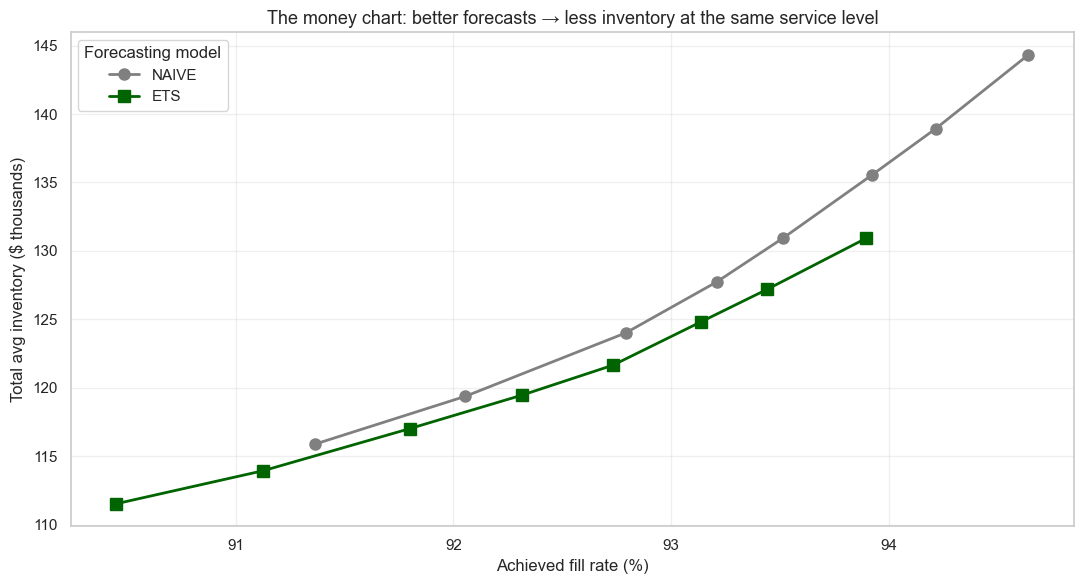

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

for model, color, marker in [("naive", "gray", "o"), ("ets", "darkgreen", "s")]:
    sub = portfolio[portfolio["model"] == model].sort_values("weighted_fill_rate")
    ax.plot(sub["weighted_fill_rate"] * 100, sub["total_inventory_dollars"] / 1000,
            marker=marker, label=model.upper(), color=color, linewidth=2, markersize=8)

ax.set_xlabel("Achieved fill rate (%)", fontsize=12)
ax.set_ylabel("Total avg inventory ($ thousands)", fontsize=12)
ax.set_title("The money chart: better forecasts → less inventory at the same service level",
             fontsize=13)
ax.legend(title="Forecasting model", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_money_chart.png", dpi=120, bbox_inches="tight")
plt.show()

In [16]:
# Pick a target service level and report the savings
target = 0.95
nearest_target = portfolio["service_level"][
    (portfolio["service_level"] - target).abs().argmin()
]

at_target = portfolio[portfolio["service_level"] == nearest_target]
inv_naive = at_target[at_target["model"] == "naive"]["total_inventory_dollars"].values[0]
inv_ets = at_target[at_target["model"] == "ets"]["total_inventory_dollars"].values[0]

savings = inv_naive - inv_ets
savings_pct = (savings / inv_naive) * 100


print(f"HEADLINE RESULT — at target service level {nearest_target}")

print(f"  Avg inventory under naive forecasts: ${inv_naive:,.0f}")
print(f"  Avg inventory under ETS forecasts:   ${inv_ets:,.0f}")
print(f"  Savings:                             ${savings:,.0f}  ({savings_pct:.1f}%)")


HEADLINE RESULT — at target service level 0.95
  Avg inventory under naive forecasts: $130,942
  Avg inventory under ETS forecasts:   $121,648
  Savings:                             $9,294  (7.1%)


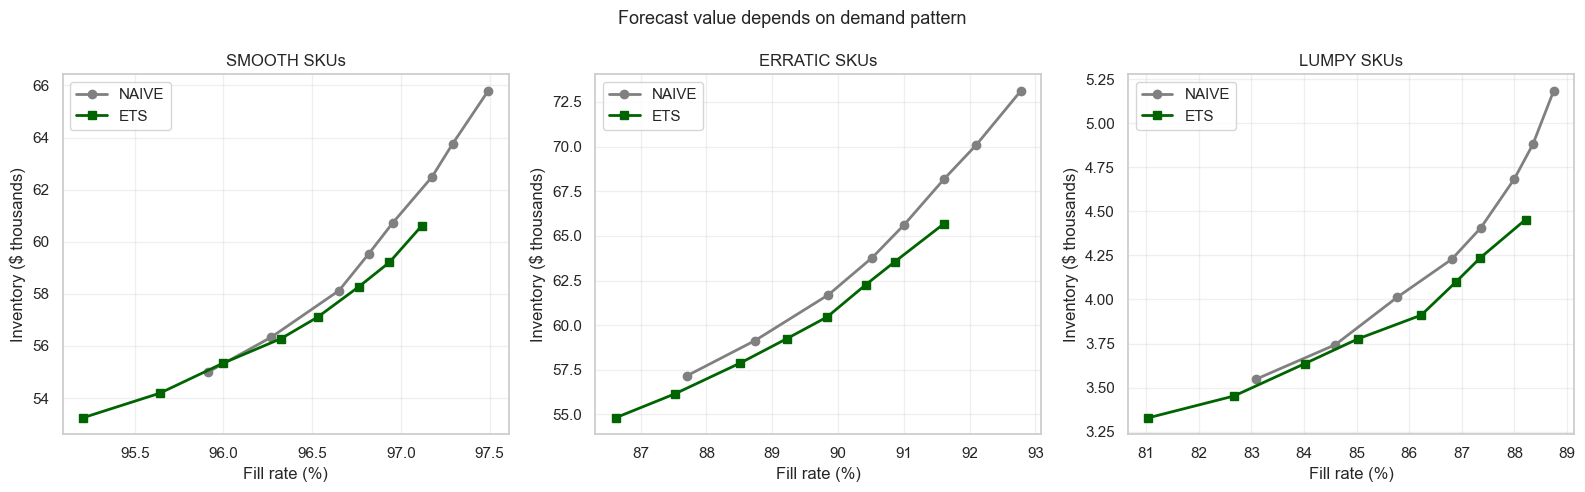

In [18]:
sim_df_w_pattern = sim_df.merge(modeling_skus[["id", "pattern"]], on="id", how="left")

# Compute portfolio metrics by pattern
by_pattern = sim_df_w_pattern.groupby(["pattern", "model", "service_level"]).agg(
    inventory_dollars=("avg_inventory_$", "sum"),
    fill_rate=("fill_rate", lambda x: np.average(
        x, weights=sim_df_w_pattern.loc[x.index, "total_demand"].clip(lower=1)
    ))
).reset_index()

# Plot one panel per pattern
patterns_to_plot = ["smooth", "erratic", "lumpy"]  # skip intermittent (only 5 SKUs)
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, pattern in zip(axes, patterns_to_plot):
    sub = by_pattern[by_pattern["pattern"] == pattern]
    for model, color, marker in [("naive", "gray", "o"), ("ets", "darkgreen", "s")]:
        m_sub = sub[sub["model"] == model].sort_values("fill_rate")
        ax.plot(m_sub["fill_rate"] * 100, m_sub["inventory_dollars"] / 1000,
                marker=marker, label=model.upper(), color=color, linewidth=2)
    ax.set_title(f"{pattern.upper()} SKUs")
    ax.set_xlabel("Fill rate (%)")
    ax.set_ylabel("Inventory ($ thousands)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Forecast value depends on demand pattern", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_money_chart_by_pattern.png", dpi=120, bbox_inches="tight")
plt.show()

## Inventory Simulation — Key Findings

**Setup:**
- Lead time: 7 days
- Order quantity: 28 × average daily demand (~4 weeks of supply per order)
- Lost-sales assumption (customers walk away rather than backorder)
- Service levels swept: 80% to 99%
- Test period: 28 days
- 1,437 SKUs from FOODS category at store CA_1

**Method:**
1. Forecast error standard deviation (σ) per SKU was computed from the validation period — the 28 days immediately *before* the test window. This mirrors how a demand planner sizes safety stock in practice: from recent observed forecast error, not from data the policy hasn't seen yet.
2. For each (SKU × service level × forecasting model), reorder point = (avg daily demand × lead time) + z × σ × √L, where z is the service-level factor and L is the lead time.
3. A day-by-day inventory simulation was run for each policy over the 28-day test period using actual demand. Each day: orders arriving were received, demand hit (lost sales if insufficient inventory), then the reorder trigger was evaluated.

### Headline result

| Metric | Seasonal naive | ETS | Improvement |
|---|---|---|---|
| Mean forecast error σ per SKU | 2.34 units | 1.66 units | **−29%** |
| Avg inventory at 95% target service level | $130,942 | $121,648 | **−$9,294 (−7.1%)** |

**Forecast error standard deviation dropped 29% under ETS** versus seasonal naive across the catalog. In the simulated reorder-point policy at 95% target service level over 28 days, that translated to **$9,294 in reduced average inventory investment — a 7.1% reduction** — driven by lower safety stock requirements.

### Why the inventory savings are smaller than the σ improvement

The 29% σ reduction does not translate 1-for-1 into a 29% inventory reduction. Total inventory has two components:

- **Cycle stock** — set by the order quantity (Q = 28 days of supply). Unaffected by forecast quality. Dominates total inventory level.
- **Safety stock** — set by z × σ × √L. Scales directly with σ.

Only safety stock responds to forecast accuracy. With a four-week order quantity, cycle stock makes up the larger share of total inventory, which dampens the percentage gain at the portfolio level. **This is a real and intuitive supply chain finding, not a project limitation**: in catalogs where cycle stock dominates, the marginal value of better forecasts is bounded.

### Where the value concentrates

Looking at the per-pattern money chart, ETS produces the largest inventory savings on **smooth SKUs** (predictable demand → big benefit from accurate forecasts). On **lumpy SKUs**, the two curves are essentially overlapping — when demand is genuinely random, no forecasting method materially reduces required safety stock. This decomposition matters for prioritization: a real planning team would invest in better forecasts for the smooth and erratic core of the catalog, and treat lumpy SKUs with a different policy (higher safety stock, manual review, or pooled multi-location stocking).

### Scaling intuition

$9,294 in inventory savings over 28 days on one store, one category extrapolates to approximately **$120K/year per store per category**. For a multi-store retailer with dozens of categories, small percentage improvements compound into millions in working-capital reduction — which is why even modest forecast accuracy gains attract investment at scale.

### Caveats and assumptions

These would be the first things to address in a more rigorous follow-up:

- **The √L scaling assumes independent daily forecast errors.** In reality, errors are autocorrelated (a forecast miss today predicts a miss tomorrow), so true lead-time error std is typically higher than σ × √L. A bootstrap convolution would be more accurate.
- **Normally distributed forecast errors.** The z × σ formula assumes Gaussian errors. For lumpy and intermittent SKUs, errors are heavily right-skewed; the normal approximation overstates required safety stock at low service levels and understates it at high service levels. Empirical quantile-based safety stock would be a more defensible approach for those patterns.
- **Lost-sales assumption is conservative.** A backorder assumption (customers wait) would yield lower inventory at the same fill rate.
- **Single lead time across all SKUs.** Real supply chains have supplier-specific lead times, and longer-lead-time SKUs need disproportionately more safety stock.
- **Order quantity is heuristic, not optimized.** A proper EOQ calculation incorporating holding cost and ordering cost would re-balance cycle stock vs. safety stock.
- **ETS used as the "good" model rather than LightGBM.** ETS narrowly beat LightGBM on WMAPE in this slice (61.4% vs 63.6%) because erratic SKUs dominate. A hybrid policy — LightGBM on smooth, ETS on erratic, naive on intermittent — would likely produce additional savings.

### What this proves about the project's central question

The project asked: "Better forecasts should mean less inventory at the same service level — but how much less, and is the difference worth the modeling complexity?"

**Answer for this slice:** A 29% improvement in forecast error standard deviation yields a 7.1% reduction in inventory at 95% service level. The transmission ratio is bounded by how much of total inventory is safety stock vs. cycle stock; in this scenario, cycle stock dominates. The most defensible business case for forecast investment is in catalogs where (a) safety stock makes up a larger share of total inventory, and (b) demand patterns are smooth or erratic rather than lumpy.


In [19]:
# Save simulation results with pattern info for the dashboard
sim_export = sim_df.merge(modeling_skus[["id", "pattern"]], on="id", how="left")
sim_export = sim_export.rename(columns={"avg_inventory_$": "avg_inventory_dollars"})
sim_export.to_parquet(PROCESSED_DIR / "sim_results_w_pattern.parquet", index=False)
print(f"Saved sim results with pattern: {sim_export.shape}")

Saved sim results with pattern: (17312, 14)
